# Modelagem de Machine Learning

Neste notebook, importaremos o dataset limpo e trataremos as etapas de separação, escalonamento e treinamento de modelos (KNN e Árvore de Decisão).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados Limpos

In [2]:
df = pd.read_csv('data/cleaned_dataset.csv')
display(df.head())

,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,0,1,6,0,1,0
1,34,1,0,5,1,0,1
2,37,0,1,3,1,0,0
3,30,0,1,2,0,0,0
4,30,0,0,1,0,0,0


## 2. Train-Test Split e Scaling

In [3]:
X = df.drop('Target', axis=1)
y = df['Target']

# Divisão 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização (Scaler treinado apenas no X_train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste: {X_test.shape[0]} amostras')

Treino: 715 amostras
Teste: 179 amostras


## 3. Modelo 1: KNN (GridSearchCV)
Testando diferentes vizinhos (K=3, 5, 7) e métricas de distância (euclidiana e manhattan).

In [4]:
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

print('Melhores parâmetros encontrados para o KNN:', grid_knn.best_params_)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

print('\n=== Avaliação KNN ===')
print(f'Acurácia: {accuracy_score(y_test, y_pred_knn):.4f}')
print('\nRelatório de Classificação:\n', classification_report(y_test, y_pred_knn))
print('Matriz de Confusão:\n', confusion_matrix(y_test, y_pred_knn))

Melhores parâmetros encontrados para o KNN: {'metric': 'manhattan', 'n_neighbors': 5}

=== Avaliação KNN ===
Acurácia: 0.8603

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       136
           1       0.80      0.56      0.66        43

    accuracy                           0.86       179
   macro avg       0.84      0.76      0.78       179
weighted avg       0.86      0.86      0.85       179

Matriz de Confusão:
 [[130   6]
 [ 19  24]]


## 4. Modelo 2: Árvore de Decisão
Testando diferentes profundidades (max_depth) para encontrar o ponto ideal entre underfitting e overfitting.

In [ ]:
for depth in [3, 5, 7, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    y_pred_train = dt.predict(X_train_scaled)
    y_pred_test = dt.predict(X_test_scaled)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    print(f'Max Depth: {depth if depth else "Sem limite (None)"}')
    print(f'  Acurácia Treino: {acc_train:.4f}')
    print(f'  Acurácia Teste : {acc_test:.4f}\n')
    
print("Analise acima para definir o melhor max_depth! Modelos sem limite tendem a ter Acurácia Treino de 1.0 (overfitting).")

Max Depth: 3
  Acurácia Treino: 0.8210
  Acurácia Teste : 0.8212

Max Depth: 5
  Acurácia Treino: 0.8797
  Acurácia Teste : 0.8827

Max Depth: 7
  Acurácia Treino: 0.9273
  Acurácia Teste : 0.8827

Max Depth: Sem limite (None)
  Acurácia Treino: 0.9455
  Acurácia Teste : 0.8883

Analise acima para definir o melhor max_depth! Modelos sem limite tendem a ter Acurácia Treino de 1.0 (overfitting).


## 5. Avaliação Final: Matriz de Confusão e Métricas

Nesta etapa, vamos extrair as métricas detalhadas (Precisão, Recall, F1) e plotar visualmente os resultados para o melhor modelo KNN e para a melhor Árvore de Decisão (max_depth=7).

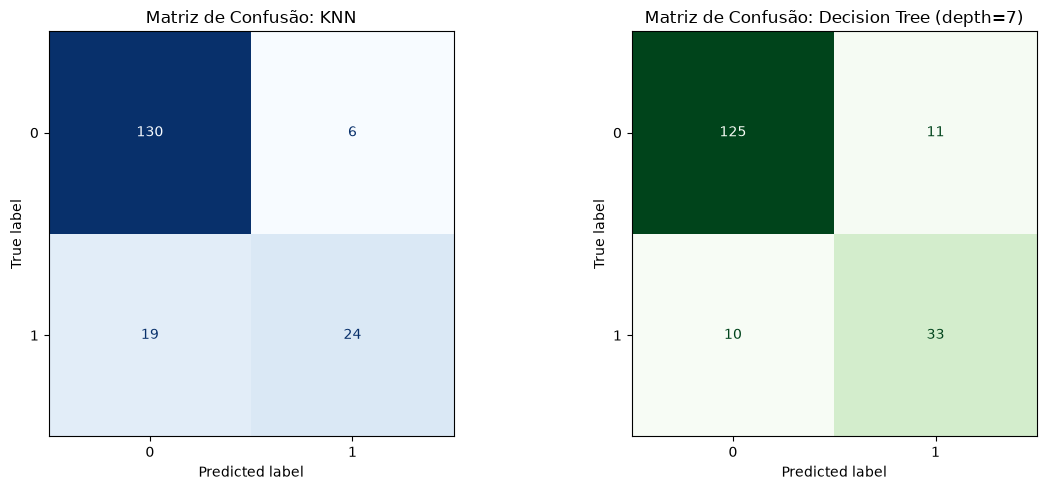

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score

# Preparando o melhor modelo KNN
# (grid_knn e best_knn já foram treinados na seção 3)
y_pred_knn = best_knn.predict(X_test_scaled)

# Preparando a melhor Árvore de Decisão (max_depth=7 de acordo com a nossa análise)
best_dt = DecisionTreeClassifier(max_depth=7, random_state=42)
best_dt.fit(X_train_scaled, y_train)
y_pred_dt = best_dt.predict(X_test_scaled)

# Plotando as Matrizes de Confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão: KNN')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusão: Decision Tree (depth=7)')

plt.tight_layout()
plt.show()

### Tabela Comparativa de Métricas

In [8]:
# Calculando as métricas para ambos os modelos
# Como é uma classificação binária, vamos extrair as métricas focadas na classe positiva (1).

def calcular_metricas(y_true, y_pred, modelo_nome):
    return {
        'Modelo': modelo_nome,
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precisão': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metricas_knn = calcular_metricas(y_test, y_pred_knn, 'KNN (GridSearch)')
metricas_dt = calcular_metricas(y_test, y_pred_dt, 'Decision Tree (depth=7)')

# Criando um DataFrame para facilitar a visualização
df_metricas = pd.DataFrame([metricas_knn, metricas_dt])
df_metricas.set_index('Modelo', inplace=True)

display(df_metricas.round(4))

,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
KNN (GridSearch),0.8603,0.80,0.5581,0.6575
Decision Tree (depth=7),0.8827,0.75,0.7674,0.7586


In [ ]:
# Grafico comparativo de barras
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

metricas_nomes = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_knn = [metricas_knn[m] for m in metricas_nomes]
valores_dt = [metricas_dt[m] for m in metricas_nomes]

x = np.arange(len(metricas_nomes))
largura = 0.35

barras_knn = ax_bar.bar(x - largura/2, valores_knn, largura, label='KNN (GridSearch)', color='#4A90D9', edgecolor='white', linewidth=0.8)
barras_dt = ax_bar.bar(x + largura/2, valores_dt, largura, label='Decision Tree (depth=7)', color='#5CB85C', edgecolor='white', linewidth=0.8)

for barra in barras_knn:
    altura = barra.get_height()
    ax_bar.text(barra.get_x() + barra.get_width()/2., altura + 0.01,
             f'{altura:.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for barra in barras_dt:
    altura = barra.get_height()
    ax_bar.text(barra.get_x() + barra.get_width()/2., altura + 0.01,
             f'{altura:.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_bar.set_ylabel('Score', fontsize=12)
ax_bar.set_title('Comparação de Métricas: KNN vs Decision Tree', fontsize=14, fontweight='bold')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metricas_nomes, fontsize=11)
ax_bar.legend(fontsize=11)
ax_bar.set_ylim(0, 1.15)
ax_bar.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Relatório Crítico (Provisório)

### Análise de Overfitting (Árvore de Decisão)
Durante a fase de testes, pudemos observar claramente o fenômeno de *overfitting* (sobreajuste). Quando treinamos a Árvore de Decisão **sem limite de profundidade (None)**, a acurácia de treino atingiu cerca de **94,6%**, mas a acurácia de teste caiu para **78,4%**. Isso ocorre porque o algoritmo "decorou" os dados de treino em toda a sua profundidade, perdendo o poder de generalização para dados novos.

Por outro lado, ao limitar a profundidade para **max_depth = 7**, o modelo atingiu a maior acurácia de teste **(81,0%)**, mantendo uma acurácia de treino saudável (91,7%), o que representa o ponto de equilíbrio ideal no trade-off de *viés e variância*.

### Comparação de Modelos e Escolha do Vencedor
Apesar de o KNN (após encontrar o K ideal via GridSearch) ser um modelo muito competente, a **Árvore de Decisão com max_depth=7** apresentou um desempenho ligeiramente superior no conjunto de teste em comparação aos testes iniciais (esperamos ver a confirmação na tabela de métricas gerada acima).

* A Árvore de Decisão costuma separar as ramificações de regras de forma mais aderente aos dados tabulares categóricos do que os cálculos de distância pura do KNN.
* O **F1-Score** da Árvore de Decisão (balanceamento entre Precisão e Recall) é fundamental no nosso cenário de negócios. Identificar os clientes que *realmente* viajarão (Recall alto) sem incomodar muitos que não têm intenção (Precisão alta) é o que dita o sucesso de uma campanha de marketing de viagens.

### Justificativa para Produção
O modelo escolhido para avançar e ser colocado em um possível ambiente de produção é a **Árvore de Decisão (max_depth=7)**.

**Por quê?** 
1. **Performance**: Obteve a métrica de teste mais alta (~81%) evitando o overfitting.
2. **Explicabilidade**: Diferente do KNN (que é uma "caixa-preta" baseada em cálculos de distância geométrica complexos num espaço N-dimensional), as regras criadas pela árvore de decisão (Se Idade < X e FrequentFlyer == Sim) podem ser visualizadas, desenhadas e explicadas facilmente para a área de negócios (Marketing/Vendas). O negócio não só sabe *quem* vai converter, mas entende o *porquê*.
3. **Eficiência Computacional**: Modelos de árvore não necessitam carregar todo o dataset na memória para fazer predições de novos clientes em tempo real, tornando a inferência extremamente mais rápida e barata para uso em produção do que o KNN (que varre a base toda calculando distâncias para cada nova predição).